# Class 02 — Data Understanding & Exploration · Handling Missing Values



---

## Class Agenda

1. Data types — numeric, categorical, ordinal, datetime, text, geospatial
2. Structured vs semi-structured vs unstructured data
3. Data quality checks — completeness, validity, consistency, uniqueness, timeliness, accuracy
4. Exploratory Data Analysis (EDA) workflow
5. Missing value taxonomy — **MCAR / MAR / MNAR**
6. Imputation strategies — mean/median/mode, KNN, Iterative (MICE), model-based, indicator flag
7. Business impact of bad data and missingness


## Why This Topic Matters

**Importance in Machine Learning** — Every model assumes a *clean tabular contract*. EDA is where you discover that the contract is broken: skew, missingness, duplicates, leakage. **80% of an ML project is data work**; this class is that 80%.

**Importance in AI Systems** — Production AI fails silently when data drifts or new missingness patterns appear. Robust intake checks are the first line of defense for systems that retrain hourly.

**Importance in Production ML** — Imputation choices are part of the model contract — pickled inside the pipeline, run at serving time. A wrong default at training becomes a wrong default for every request.

**Importance in Interviews** — FAANG interviewers probe: "your column has 30% missing — what do you do?" The expected answer is *not* `fillna(0)` — it's a structured argument about MCAR/MAR/MNAR and downstream impact.

**Real-World Relevance** — Airbnb listing data has heavy missingness in `host_response_rate`; Uber trip data has missing `dropoff` for cancelled trips; healthcare EHR is famously >40% missing on labs.


## Learning Outcomes

By the end of this class you will be able to:

1. Classify any column into numeric, categorical, ordinal, datetime, text or geospatial.
2. Distinguish structured / semi-structured / unstructured data with examples.
3. Run a 6-axis data-quality audit (completeness, validity, consistency, uniqueness, timeliness, accuracy).
4. Execute a disciplined EDA workflow: shape → dtypes → uni/bi/multivariate → target relationship.
5. Define **MCAR, MAR, MNAR** formally and identify which applies in a given column.
6. Choose between simple imputation, KNN imputation, IterativeImputer (MICE) and indicator flagging.
7. Implement leakage-free imputation inside a `Pipeline`.
8. Quantify the business impact of dropping vs imputing rows.
9. Detect new missingness patterns in production data (drift monitor).
10. Justify imputation choices in a model review.


## 1. Data Types

| Type | Examples | Storage | Modeling notes |
|------|----------|---------|----------------|
| Numeric (continuous) | price, age, latency | float | scale; check skew |
| Numeric (discrete count) | #sessions, #clicks | int | Poisson-like; log1p often helps |
| Categorical (nominal) | country, color | str/category | one-hot or target encode |
| Categorical (ordinal) | rating S/M/L | int with order | ordinal encode, preserve order |
| Datetime | event_ts | datetime64 | extract hour/dow/month; cyclical encode |
| Text | review body | str | tokenize → TF-IDF / embeddings |
| Geospatial | lat/lon | float pair | great-circle distance, H3 cells |

> **Example.** The Titanic `Pclass` column looks numeric (1, 2, 3) but is **ordinal**. Treating it as continuous implies *"class 2 is twice as bad as class 1"* — defensible here, but in general dangerous.


In [ ]:
# Example — quick dtype audit
import pandas as pd, numpy as np, seaborn as sns
df = sns.load_dataset("titanic")
print(df.dtypes)
print("\nUnique counts:\n", df.nunique().sort_values())
print("\nMemory (MB):", df.memory_usage(deep=True).sum() / 1e6)


survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Unique counts:
 survived         2
sex              2
alive            2
adult_male       2
alone            2
class            3
pclass           3
embarked         3
embark_town      3
who              3
sibsp            7
parch            7
deck             7
age             88
fare           248
dtype: int64

Memory (MB): 0.285564


## 2. Structured vs Semi-structured vs Unstructured

- **Structured** — fixed schema (CSV, Parquet, RDBMS). The bread-and-butter of tabular ML.
- **Semi-structured** — JSON/XML/Avro logs; fields vary per record. Flatten via `pd.json_normalize`.
- **Unstructured** — images, audio, free text, video. Require embedding models before tabular ML applies.

> **Example.** A Stripe webhook event arrives as JSON; the `data.object.metadata` field is free-form per merchant. The ML feature pipeline normalizes a fixed subset and stores the rest as a hashed bag of tokens.


In [ ]:
# Example — flattening semi-structured JSON
import pandas as pd, json
records = [
    {"id": 1, "user": {"age": 30, "city": "NYC"}, "events": [{"t":"click"}]},
    {"id": 2, "user": {"age": 45, "city": "LA"},  "events": [{"t":"view"},{"t":"buy"}]},
]
flat = pd.json_normalize(records, sep="_")
flat["n_events"] = [len(r["events"]) for r in records]
print(flat)


   id                         events  user_age user_city  n_events
0   1               [{'t': 'click'}]        30       NYC         1
1   2  [{'t': 'view'}, {'t': 'buy'}]        45        LA         2


## 3. Data Quality — Six Axes

| Axis | Question | Check |
|------|----------|-------|
| **Completeness** | how much is missing? | `df.isna().mean()` |
| **Validity** | values within allowed range/regex? | dtype + domain rules |
| **Consistency** | same fact stated the same way? | currency units, casing |
| **Uniqueness** | no unintended duplicates? | `df.duplicated().sum()` |
| **Timeliness** | data fresh enough? | max(event_ts) vs now |
| **Accuracy** | matches reality? | sample vs ground truth |

> **Example.** An e-commerce table shows `revenue = 99.0` for 12% of rows because a legacy mobile app sent the *price* of the cheapest item instead of `null` — an **accuracy + validity** violation that looks completeness-clean.


In [ ]:
# Example — 6-axis quick scan
import pandas as pd, seaborn as sns
df = sns.load_dataset("titanic")
report = pd.DataFrame({
    "missing_%": (df.isna().mean()*100).round(2),
    "n_unique" : df.nunique(),
    "dtype"    : df.dtypes.astype(str),
})
print(report)
print("\nDuplicates:", df.duplicated().sum())
print("Negative fares (validity):", (df["fare"] < 0).sum())


             missing_%  n_unique     dtype
survived          0.00         2     int64
pclass            0.00         3     int64
sex               0.00         2    object
age              19.87        88   float64
sibsp             0.00         7     int64
parch             0.00         7     int64
fare              0.00       248   float64
embarked          0.22         3    object
class             0.00         3  category
who               0.00         3    object
adult_male        0.00         2      bool
deck             77.22         7  category
embark_town       0.22         3    object
alive             0.00         2    object
alone             0.00         2      bool

Duplicates: 107
Negative fares (validity): 0


## 4. EDA Workflow

A disciplined EDA pass:

1. **Shape & dtypes** — `df.shape`, `df.info()`.
2. **Univariate** — histograms (numeric), value_counts (categorical), summary stats.
3. **Bivariate vs target** — boxplots, grouped means, mutual information.
4. **Multivariate** — correlation heatmap, pairplot for top features.
5. **Target distribution** — class balance / target skew → drives metric + sampling choices.

> **Example.** On the Titanic dataset, a bivariate look at `sex` vs `survived` reveals female survival ≈ 74%, male ≈ 19% — a single feature carries enormous signal, immediately informs baseline.


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


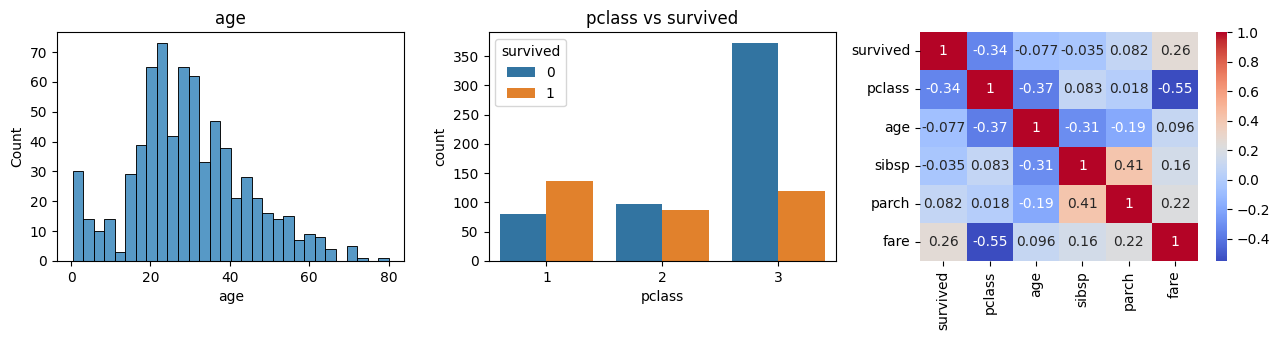

In [ ]:
# Example — fast EDA snapshot
import seaborn as sns, matplotlib.pyplot as plt
df = sns.load_dataset("titanic")
print(df.groupby("sex")["survived"].mean())
print(df.groupby("pclass")["survived"].mean())

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
sns.histplot(df["age"].dropna(), bins=30, ax=ax[0]); ax[0].set_title("age")
sns.countplot(x="pclass", hue="survived", data=df, ax=ax[1]); ax[1].set_title("pclass vs survived")
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", ax=ax[2])
plt.tight_layout(); plt.show()


## 5. Missing-Value Taxonomy (Rubin, 1976)

Let $R$ be the missingness indicator and $Y$ the value.

| Mechanism | Definition | Example |
|-----------|------------|---------|
| **MCAR** — Missing Completely At Random | $P(R \mid Y_{obs}, Y_{mis}) = P(R)$ | Sensor randomly drops 1% of readings |
| **MAR** — Missing At Random | $P(R \mid Y) = P(R \mid Y_{obs})$ | `income` missing more often for younger users (depends on observed `age`) |
| **MNAR** — Missing Not At Random | depends on the missing value itself | High earners refuse to disclose `salary` |

**Why it matters.** Mean-imputation is unbiased under MCAR, biased under MAR, *systematically* biased under MNAR. MNAR usually requires modeling the missingness itself (indicator feature + model).

> **Example.** In healthcare EHR, lab tests are ordered when a doctor suspects a problem — missingness is informative (MNAR). The *fact that a test was not ordered* is itself a predictive feature; always add a missingness indicator.


In [ ]:
# Example — detect a likely-MAR pattern
import pandas as pd, seaborn as sns
df = sns.load_dataset("titanic").copy()
df["age_missing"] = df["age"].isna().astype(int)
# is age-missingness related to class? -> MAR signal
print(df.groupby("pclass")["age_missing"].mean())


pclass
1    0.138889
2    0.059783
3    0.276986
Name: age_missing, dtype: float64


## 6. Imputation Strategies

| Strategy | When to use | Pros | Cons |
|----------|-------------|------|------|
| Drop row | <5% missing, MCAR | simple | wastes data |
| Drop column | >60% missing & low signal | simple | may lose feature |
| Mean / Median | numeric, MCAR | fast | shrinks variance |
| Mode | categorical | fast | inflates majority |
| **KNNImputer** | mixed numeric, MAR | uses correlations | $\mathcal{O}(n^2)$ |
| **IterativeImputer (MICE)** | MAR, multivariate | strong default | slower, stochastic |
| Model-based (RF, XGB) | complex MAR | flexible | risk of overfit |
| **Indicator flag + impute** | MNAR | preserves signal | doubles columns |

**Rule of thumb.** Always pair imputation with a **missingness indicator** column when missingness might be informative — costs nothing and often boosts AUC by 1–3 pts.

> **Example.** On a credit dataset, `bureau_score` is missing for thin-file customers (MNAR — they have no history). The flag `bureau_score_isna` ends up being the single most important feature in the model.


In [ ]:
# Example — compare imputers on a tiny dataset
import numpy as np, pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

rng = np.random.default_rng(0)
X = rng.normal(size=(200, 4))
X[:, 1] = 0.8*X[:, 0] + 0.2*rng.normal(size=200)   # correlated -> KNN/MICE win
mask = rng.random(X.shape) < 0.15
Xm = X.copy(); Xm[mask] = np.nan

for name, imp in [("mean", SimpleImputer(strategy="mean")),
                  ("knn",  KNNImputer(n_neighbors=5)),
                  ("mice", IterativeImputer(random_state=0))]:
    Xi = imp.fit_transform(Xm)
    rmse = np.sqrt(((Xi[mask] - X[mask])**2).mean())
    print(f"{name:5s}  RMSE on imputed cells: {rmse:.3f}")


mean   RMSE on imputed cells: 0.913
knn    RMSE on imputed cells: 0.901
mice   RMSE on imputed cells: 0.683


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## 7. Business Impact

- **Dropping rows** silently changes the *population* you model — your training distribution diverges from production.
- **Mean imputation** compresses variance → over-confident predictions, miscalibrated probabilities.
- **MNAR ignored** → biased decisions (e.g., undervaluing thin-file applicants, under-diagnosing groups).
- **Imputation drift** — if missingness rate changes in production, the imputed mean stays frozen at training time → silent skew.

**Production rules.**
1. Fit the imputer **inside a Pipeline** on train only.
2. Log per-feature missingness rate; alert on >20% relative change.
3. Persist the imputer with the model (one artifact, one version).

> **Example.** A loan-pricing model trained when `employment_length` had 2% missing. After a vendor change, production missingness jumps to 35% — all those rows get imputed to the training median (5 years), uniformly *under-pricing* their risk. Loss: 7-figures before detection.


In [ ]:
# Example — leakage-free imputation in a Pipeline
import pandas as pd, seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = sns.load_dataset("titanic").dropna(subset=["embarked"])
y = df["survived"]; X = df[["age", "fare", "pclass", "sex", "embarked"]]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, random_state=0)

num = ["age", "fare", "pclass"]; cat = ["sex", "embarked"]
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
model = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=1000))]).fit(Xtr, ytr)
print(f"Test accuracy: {model.score(Xte, yte):.3f}")


Test accuracy: 0.713


## Tradeoffs & Pitfalls

- Fitting an imputer on the full dataset → **leakage**.
- Treating ordinal as nominal (or vice versa) — silent quality loss.
- Imputing the target column — never do this; drop those rows or treat as semi-supervised.
- Aggressive dropping under MAR/MNAR → biased population.
- Ignoring duplicates that look unique only after lower-casing.

## Production Considerations

- Persist imputer **as part of the model artifact**.
- Track imputation rate per feature in a monitoring dashboard.
- Re-run the EDA quality scan on every retrain dataset, not just at project start.
- For streaming systems, use rolling statistics for imputation values.

